C:\Users\jeane\Documents\Alternance\projet-bulkformer-lgg\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nombre de patches trouvés : 50

Fichier : patch_0000.tif
Dimensions : (3, 257, 386)
CRS : EPSG:4326
Centre GPS : lat=48.4591, lon=-0.6494


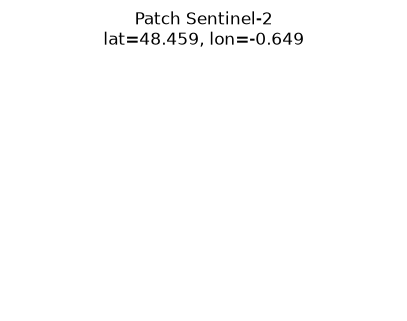

In [2]:
# Cellule 1 — Imports et vérification des patches
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import json
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

# Chemin vers les patches
PATCHES_DIR = Path("../data/sentinel2_france")
patches = sorted(PATCHES_DIR.glob("*.tif"))
print(f"Nombre de patches trouvés : {len(patches)}")

# Lire le premier patch
with rasterio.open(patches[0]) as src:
    img = src.read([1, 2, 3])
    bounds = src.bounds
    crs = src.crs
    center_lon = (bounds.left + bounds.right) / 2
    center_lat = (bounds.bottom + bounds.top) / 2
    print(f"\nFichier : {patches[0].name}")
    print(f"Dimensions : {img.shape}")
    print(f"CRS : {crs}")
    print(f"Centre GPS : lat={center_lat:.4f}, lon={center_lon:.4f}")

# Afficher le patch
img_display = np.transpose(img, (1, 2, 0))
p2, p98 = np.percentile(img_display, 2), np.percentile(img_display, 98)
img_display = np.clip((img_display - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img_display)
plt.title(f"Patch Sentinel-2\nlat={center_lat:.3f}, lon={center_lon:.3f}")
plt.axis("off")
plt.show()

In [3]:
# Cellule 2 — Chargement RemoteCLIP
model_name = "flax-community/clip-rsicd-v2"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)
model.eval()
print(f"Modèle chargé : {model_name}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22875.10it/s]

Modèle chargé : flax-community/clip-rsicd-v2


In [4]:
# Cellule 3 — Encodage des 50 patches Sentinel-2
all_embeddings = []
all_metadata = []

for i, patch_path in enumerate(patches):
    with rasterio.open(patch_path) as src:
        img_array = src.read([1, 2, 3])
        bounds = src.bounds
        center_lon = (bounds.left + bounds.right) / 2
        center_lat = (bounds.bottom + bounds.top) / 2

    # Normalisation
    img_array = img_array.astype(np.float32)
    img_array = img_array * 10000
    p2 = np.percentile(img_array[img_array > 0], 2) if np.any(img_array > 0) else 0
    p98 = np.percentile(img_array[img_array > 0], 98) if np.any(img_array > 0) else 1
    img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)
    
    # Conversion PIL — manquait dans la version précédente
    img_pil = Image.fromarray(np.transpose(img_array, (1, 2, 0)))

    # Encodage
    inputs = processor(images=img_pil, return_tensors="pt")
    with torch.no_grad():
        outputs = model.vision_model(pixel_values=inputs["pixel_values"])
        emb = model.visual_projection(outputs.pooler_output)
        emb = F.normalize(emb, dim=-1)

    all_embeddings.append(emb.numpy())
    all_metadata.append({
        "path": str(patch_path),
        "filename": patch_path.name,
        "lat": center_lat,
        "lon": center_lon,
        "bounds": {
            "left": bounds.left,
            "right": bounds.right,
            "top": bounds.top,
            "bottom": bounds.bottom
        }
    })

    if i % 10 == 0:
        print(f"Patch {i+1}/50 encodé — lat={center_lat:.3f}, lon={center_lon:.3f}")

all_embeddings = np.vstack(all_embeddings).astype("float32")
print(f"\nShape embeddings : {all_embeddings.shape}")

C:\Users\jeane\AppData\Local\Temp\ipykernel_49020\1271267167.py:17: RuntimeWarning: invalid value encountered in cast
  img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)


Patch 1/50 encodé — lat=48.459, lon=-0.649
Patch 11/50 encodé — lat=47.524, lon=1.796
Patch 21/50 encodé — lat=42.940, lon=-3.374
Patch 31/50 encodé — lat=43.485, lon=-0.956
Patch 41/50 encodé — lat=48.685, lon=7.367

Shape embeddings : (50, 512)


C:\Users\jeane\AppData\Local\Temp\ipykernel_49020\4085312531.py:14: RuntimeWarning: invalid value encountered in cast
  img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)


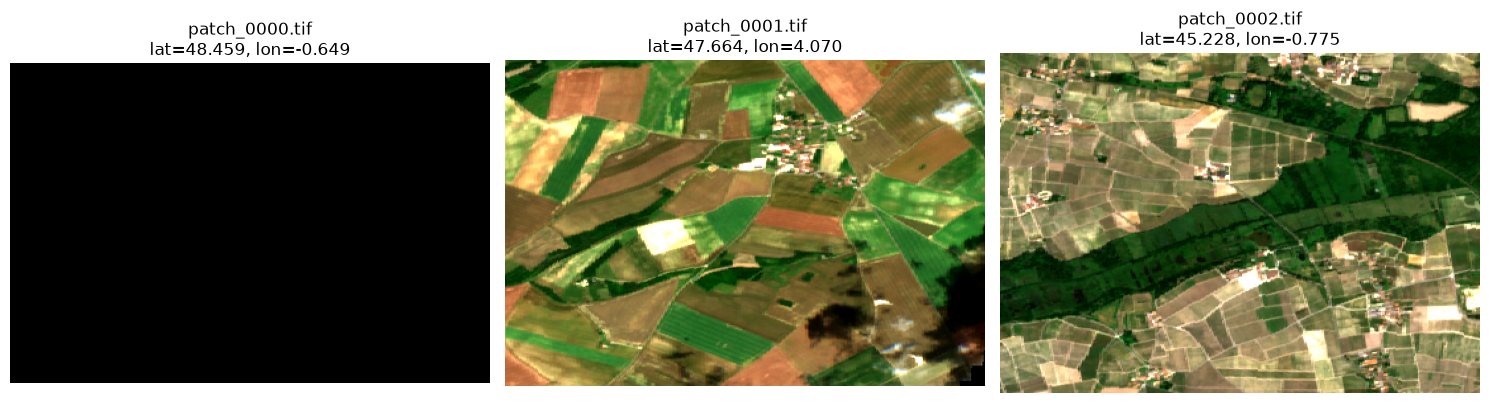

In [5]:
# Vérification affichage — 3 patches
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    with rasterio.open(patches[i]) as src:
        img_array = src.read([1, 2, 3])
        bounds = src.bounds
        center_lon = (bounds.left + bounds.right) / 2
        center_lat = (bounds.bottom + bounds.top) / 2

    img_array = img_array.astype(np.float32) * 10000
    p2 = np.percentile(img_array[img_array > 0], 2) if np.any(img_array > 0) else 0
    p98 = np.percentile(img_array[img_array > 0], 98) if np.any(img_array > 0) else 1
    img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)
    img_display = np.transpose(img_array, (1, 2, 0))

    axes[i].imshow(img_display)
    axes[i].set_title(f"{patches[i].name}\nlat={center_lat:.3f}, lon={center_lon:.3f}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Cellule 4 — Index FAISS + sauvegarde
import faiss
import pickle

# Construction index
dimension = 512
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(all_embeddings)
index.add(all_embeddings)
print(f"Index FAISS construit : {index.ntotal} vecteurs")

# Sauvegarde
faiss.write_index(index, "../data/sentinel2_index.faiss")

with open("../data/sentinel2_metadata.pkl", "wb") as f:
    pickle.dump({
        "embeddings": all_embeddings,
        "metadata": all_metadata
    }, f)

print("Sauvegardé :")
print("  - data/sentinel2_index.faiss")
print("  - data/sentinel2_metadata.pkl")

Index FAISS construit : 50 vecteurs
Sauvegardé :
  - data/sentinel2_index.faiss
  - data/sentinel2_metadata.pkl


In [7]:
# Cellule 5 — Test recherche textuelle
def search_sentinel2(query, index, model, processor, metadata_list, k=5):
    inputs = processor(text=[query], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = model.text_model(
            **{k: v for k, v in inputs.items() if k != "pixel_values"}
        )
        text_emb = model.text_projection(text_features.pooler_output)
        text_emb = F.normalize(text_emb, dim=-1).numpy().astype("float32")

    faiss.normalize_L2(text_emb)
    D, I = index.search(text_emb, k=k)

    results = []
    for rank, idx in enumerate(I[0]):
        result = metadata_list[idx].copy()
        result["score"] = float(D[0][rank])
        results.append(result)
    return results

# Tests
queries = [
    "green forest with trees",
    "urban city buildings",
    "agricultural crop fields",
    "river or lake water",
    "coastal area near sea"
]

for query in queries:
    results = search_sentinel2(query, index, model, processor, all_metadata, k=3)
    print(f"\n'{query}'")
    for r in results:
        print(f"  {r['filename']} — lat={r['lat']:.3f}, lon={r['lon']:.3f} — score={r['score']:.3f}")


'green forest with trees'
  patch_0027.tif — lat=45.324, lon=3.470 — score=0.259
  patch_0018.tif — lat=48.761, lon=8.770 — score=0.244
  patch_0014.tif — lat=45.626, lon=0.840 — score=0.242

'urban city buildings'
  patch_0021.tif — lat=49.972, lon=8.018 — score=0.204
  patch_0022.tif — lat=42.581, lon=-5.265 — score=0.194
  patch_0026.tif — lat=46.282, lon=6.071 — score=0.190

'agricultural crop fields'
  patch_0007.tif — lat=47.610, lon=3.436 — score=0.272
  patch_0006.tif — lat=48.397, lon=4.576 — score=0.270
  patch_0011.tif — lat=47.213, lon=5.119 — score=0.270

'river or lake water'
  patch_0037.tif — lat=43.588, lon=8.494 — score=0.238
  patch_0036.tif — lat=42.994, lon=5.042 — score=0.237
  patch_0018.tif — lat=48.761, lon=8.770 — score=0.237

'coastal area near sea'
  patch_0004.tif — lat=42.423, lon=3.160 — score=0.248
  patch_0042.tif — lat=49.371, lon=-2.649 — score=0.221
  patch_0035.tif — lat=42.394, lon=5.532 — score=0.218


In [8]:
# Cellule 6 — Sauvegarde résultats Phase 2
results_phase2 = {
    "model": "flax-community/clip-rsicd-v2",
    "dataset": "Sentinel-2 France (GEE)",
    "total_patches": 50,
    "embedding_dim": 512,
    "zone": "France metropolitaine",
    "crs": "EPSG:4326"
}

with open("../data/results_phase2.json", "w") as f:
    json.dump(results_phase2, f, indent=2)

print("Phase 2 sauvegardée")

Phase 2 sauvegardée


In [12]:
def is_valid_patch(img_array, threshold=0.1):
    valid = np.sum(img_array > 0)
    total = img_array.size
    return valid / total > threshold

def extract_patches(tif_path, patch_size=256, stride=128):
    patches_info = []
    with rasterio.open(tif_path) as src:
        width = src.width
        height = src.height
        transform = src.transform
        
        patch_idx = 0
        for row in range(0, height - patch_size, stride):
            for col in range(0, width - patch_size, stride):
                window = Window(col, row, patch_size, patch_size)
                img_array = src.read([1, 2, 3], window=window)
                
                if not is_valid_patch(img_array):
                    continue
                
                center_x = col + patch_size // 2
                center_y = row + patch_size // 2
                lon, lat = rasterio.transform.xy(transform, center_y, center_x)
                
                patch_name = f"{tif_path.stem}_patch_{patch_idx:04d}.tif"
                patch_path = Path(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_patches") / patch_name
                
                profile = src.profile.copy()
                profile.update(width=patch_size, height=patch_size)
                
                with rasterio.open(patch_path, 'w', **profile) as dst:
                    dst.write(img_array)
                
                patches_info.append({
                    "path": str(patch_path),
                    "filename": patch_name,
                    "lat": float(lat),
                    "lon": float(lon),
                    "source": tif_path.name
                })
                patch_idx += 1
    
    return patches_info

print("Fonctions définies")

Fonctions définies


In [14]:
import rasterio
from rasterio.windows import Window
# Découpage de toutes les zones en patches
all_patches_info = []
total = 0

ZONES_DIR = Path(r"C:\Users\jeane\Documents\Alternance\eo-image-search\sentinel2_france_5k")
PATCHES_DIR = Path(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_patches")
PATCHES_DIR.mkdir(exist_ok=True)

zones = sorted(ZONES_DIR.glob("*.tif"))
print(f"Zones trouvées : {len(zones)}")

for zone_path in zones:
    print(f"\nTraitement : {zone_path.name}")
    patches = extract_patches(zone_path, patch_size=256, stride=128)
    all_patches_info.extend(patches)
    total += len(patches)
    print(f"  → {len(patches)} patches valides")

print(f"\nTotal patches : {total}")
print(f"Sauvegardés dans : {PATCHES_DIR}")

with open(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_patches_metadata.json", "w") as f:
    json.dump(all_patches_info, f, indent=2)

print("Métadonnées sauvegardées")

Zones trouvées : 10

Traitement : france_zone_0.tif
  → 950 patches valides

Traitement : france_zone_1.tif
  → 950 patches valides

Traitement : france_zone_2.tif
  → 1275 patches valides

Traitement : france_zone_3.tif
  → 950 patches valides

Traitement : france_zone_4.tif
  → 863 patches valides

Traitement : france_zone_5.tif
  → 1111 patches valides

Traitement : france_zone_6.tif
  → 1327 patches valides

Traitement : france_zone_7.tif
  → 848 patches valides

Traitement : france_zone_8.tif
  → 1057 patches valides

Traitement : france_zone_9.tif
  → 531 patches valides

Total patches : 9862
Sauvegardés dans : C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_patches
Métadonnées sauvegardées


In [15]:
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np
import faiss
import pickle

# Chargement modèle
model_name = "flax-community/clip-rsicd-v2"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)
model.eval()
print(f"Modèle chargé : {model_name}")

# Chargement métadonnées
with open(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_patches_metadata.json") as f:
    all_patches_info = json.load(f)

print(f"Total patches à encoder : {len(all_patches_info)}")

# Encodage
all_embeddings = []
errors = 0

for i, patch_info in enumerate(all_patches_info):
    try:
        with rasterio.open(patch_info["path"]) as src:
            img_array = src.read([1, 2, 3])

        img_array = img_array.astype(np.float32) * 10000
        valid_pixels = img_array[img_array > 0]
        if len(valid_pixels) < img_array.size * 0.1:
            all_embeddings.append(np.zeros(512, dtype=np.float32))
            continue

        p2, p98 = np.percentile(valid_pixels, 2), np.percentile(valid_pixels, 98)
        img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)
        img_pil = Image.fromarray(np.transpose(img_array, (1, 2, 0)))

        inputs = processor(images=img_pil, return_tensors="pt")
        with torch.no_grad():
            outputs = model.vision_model(pixel_values=inputs["pixel_values"])
            emb = model.visual_projection(outputs.pooler_output)
            emb = F.normalize(emb, dim=-1)

        all_embeddings.append(emb.numpy()[0])

    except Exception as e:
        all_embeddings.append(np.zeros(512, dtype=np.float32))
        errors += 1

    if i % 500 == 0:
        print(f"Patch {i}/{len(all_patches_info)} encodé")

all_embeddings = np.vstack(all_embeddings).astype("float32")
print(f"\nShape embeddings : {all_embeddings.shape}")
print(f"Erreurs : {errors}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 20948.62it/s]


Modèle chargé : flax-community/clip-rsicd-v2
Total patches à encoder : 9862


C:\Users\jeane\AppData\Local\Temp\ipykernel_49020\3807137816.py:38: RuntimeWarning: invalid value encountered in cast
  img_array = np.clip((img_array - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)


Patch 0/9862 encodé
Patch 500/9862 encodé
Patch 1000/9862 encodé
Patch 1500/9862 encodé
Patch 2000/9862 encodé
Patch 2500/9862 encodé
Patch 3000/9862 encodé
Patch 3500/9862 encodé
Patch 4000/9862 encodé
Patch 4500/9862 encodé
Patch 5000/9862 encodé
Patch 5500/9862 encodé
Patch 6000/9862 encodé
Patch 6500/9862 encodé
Patch 7000/9862 encodé
Patch 7500/9862 encodé
Patch 8000/9862 encodé
Patch 8500/9862 encodé
Patch 9000/9862 encodé
Patch 9500/9862 encodé

Shape embeddings : (9862, 512)
Erreurs : 0


In [16]:
# Construction index FAISS
dimension = 512
index = faiss.IndexFlatIP(dimension)

embeddings_copy = all_embeddings.copy()
faiss.normalize_L2(embeddings_copy)
index.add(embeddings_copy)
print(f"Index FAISS construit : {index.ntotal} vecteurs")

# Sauvegarde index
faiss.write_index(index, r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_index.faiss")

# Sauvegarde métadonnées
with open(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\sentinel2_metadata.pkl", "wb") as f:
    pickle.dump({
        "embeddings": all_embeddings,
        "metadata": all_patches_info
    }, f)

# Sauvegarde résultats Phase 2
results_phase2 = {
    "model": "flax-community/clip-rsicd-v2",
    "dataset": "Sentinel-2 France (GEE)",
    "total_patches": len(all_patches_info),
    "embedding_dim": 512,
    "zone": "France metropolitaine",
    "crs": "EPSG:4326"
}

with open(r"C:\Users\jeane\Documents\Alternance\eo-image-search\data\results_phase2.json", "w") as f:
    json.dump(results_phase2, f, indent=2)

print("Tout sauvegardé :")
print(f"  - sentinel2_index.faiss")
print(f"  - sentinel2_metadata.pkl")
print(f"  - results_phase2.json")

Index FAISS construit : 9862 vecteurs
Tout sauvegardé :
  - sentinel2_index.faiss
  - sentinel2_metadata.pkl
  - results_phase2.json
